# Predicting the Popularity of Online News

**Author:** Habib Kazemi  
**Course:** Big Data Analytics and Text Mining + 3CFU Project Work  
**Professor:** Dr. Stefano Lodi  
**Academic Year:** 2024-2025

---

## Classification Algorithms Implemented

This notebook implements **3 out of 6** classification algorithms using PySpark MLlib:

1. **Logistic Regression**
2. **Naive Bayes**  
3. **Decision Tree Classifier**

> **Note:** The other 3 algorithms ( Random Forest, Gradient-Boosted Tree, Support Vector Machine) are implemented in the companion notebook: `big_data_6cfu.ipynb`

## Methodology

This notebook uses **PySpark MLlib** to predict online news article popularity using a **binary classification approach** with **rolling window time-series validation**, following the methodology from the reference paper.

# Data Sources and References

## Dataset
**Online News Popularity Data Set** - [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+News+Popularity)

##  Main Reference Paper

**Fernandes, K., Vinagre, P., & Cortez, P. (2015).** *A Proactive Intelligent Decision Support System for Predicting the Popularity of Online News.* In Portuguese Conference on Artificial Intelligence (EPIA 2015). Springer.

🔗 **Available at:** [Semantic Scholar](https://api.semanticscholar.org/CorpusID:7477506)


# Introduction

## Methodology Overview

This project follows the **rolling window time-series validation** approach as described in the reference paper to ensure robust model evaluation while respecting temporal dependencies in the data.

## Machine Learning Pipeline

I implemented **6 different classification algorithms** using **PySpark MLlib**, distributed across two notebooks:

### **Current Notebook (3CFU):**
1. **Logistic Regression**
2. **Naive Bayes**
3. **Decision Tree Classifier**

### **Companion Notebook (6CFU):**
1. **Random Forest Classifier**
2. **Gradient-Boosted Tree Classifier**
3. **Support Vector Machine (SVM) Classifier**



## Evaluation Metrics

All models are evaluated using comprehensive performance metrics:
- **ROC Curves** and **AUC (Area Under Curve)**
- **Accuracy**
- **F1-Score**
- **Precision** 
- **Recall**

This multi-metric approach provides a holistic view of model performance for binary classification of news article popularity.

## Python Environment and Library Requirements

### **Python Version Used**
- **Python**: 3.11

### **Required Libraries and Minimum Versions:**

| Library | Version |
|---------|---------|
| **matplotlib** | 3.10.0 |
| **numpy** | 1.26.4 |
| **pandas** | 2.3.3  |
| **pyspark** | 4.1.1 |
| **scikit-learn** | 1.8.0 | 


# 1. Experimental Setting

**Hardware Environment:**
* **Machine Type:** MacBook Air
* **Processor:** Apple M3
* **Cores:** 8 Cores (4 Performance / 4 Efficiency)
* **RAM:** 16 GB


In [1]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col, row_number
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, LinearSVC, LogisticRegression, NaiveBayes, DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("NewsPopularityClassification_6CFU") \
    .config("spark.driver.memory", "4g") \
    .config("spark.rpc.message.maxSize", str(2047)) \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Version: {spark.version}")
print("Spark Session initialized successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/02 21:26:17 WARN Utils: Your hostname, Habibs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.188 instead (on interface en0)
26/02/02 21:26:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/02 21:26:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1
Spark Session initialized successfully!


## 1. Data Loading and Exploration

In [2]:
# Load the dataset
data = spark.read.csv("OnlineNewsPopularity.csv", header=True, inferSchema=True)

# Clean column names (remove leading/trailing spaces)
for col_name in data.columns:
    new_col = col_name.strip()
    if new_col != col_name:
        data = data.withColumnRenamed(col_name, new_col)

print(f"Total number of articles: {data.count()}")
print(f"Number of features: {len(data.columns)}")
print("\nSchema:")
data.printSchema()

Total number of articles: 39644
Number of features: 61

Schema:
root
 |-- url: string (nullable = true)
 |-- timedelta: double (nullable = true)
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: 

In [3]:
# Display basic statistics
print("Sample data:")
data.show(5)

print("\nShares distribution:")
data.select("shares").describe().show()

Sample data:
+--------------------+---------+--------------+----------------+---------------+----------------+------------------------+---------+--------------+--------+----------+--------------------+------------+-------------------------+-----------------------------+-------------------+----------------------+--------------------+---------------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-------------------------+-------------------------+--------------------------+-----------------+------------------+--------------------+-------------------+-----------------+-------------------+-----------------+----------+---------------+---------------+---------------+---------------+---------------+-------------------+-------------------------+--------------------------+--------------------------+-------------------+-------------------+---------------------+---------------------+---------------------+---------------------+-------------

## 2. Data Preprocessing

### 2.1 Binary Label Creation
Using threshold of 1,400 shares as per the original paper.

In [4]:
# Create binary label: 1 if shares > 1400, 0 otherwise
data = data.withColumn("label", when(col("shares") > 1400, 1).otherwise(0))

# Check class distribution
print("Class distribution:")
data.groupBy("label").count().show()

# Calculate class percentages
total = data.count()
popular = data.filter(col("label") == 1).count()
unpopular = data.filter(col("label") == 0).count()
print(f"Popular (>1400 shares): {popular} ({popular/total*100:.2f}%)")
print(f"Unpopular (<=1400 shares): {unpopular} ({unpopular/total*100:.2f}%)")

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1|19562|
|    0|20082|
+-----+-----+

Popular (>1400 shares): 19562 (49.34%)
Unpopular (<=1400 shares): 20082 (50.66%)


### 2.2 Exploratory Data Analysis (EDA)
As requested, we perform descriptive statistics for the whole dataset and by class (Popular vs Unpopular).

In [5]:
# 1. Descriptive Statistics for the Whole Dataset
import pandas as pd
# Identify numerical columns (excluding 'url', 'id', etc.)
# We exclude 'label' (target) and 'timedelta' (non-predictive) from the descriptive stats of features
feature_cols = [t[0] for t in data.dtypes if t[1] in ('int', 'double') and t[0] not in ['label', 'shares', 'id', 'url', 'timedelta']]

print("Generating descriptive statistics for numeric features (Whole Dataset)...")
# Calculate describe() and convert to Pandas for better readability
# Transpose so features are rows
desc_stats = data.select(feature_cols).describe().toPandas().set_index('summary').transpose()

desc_stats

Generating descriptive statistics for numeric features (Whole Dataset)...


summary,count,mean,stddev,min,max
n_tokens_title,39644,10.398748864897588,2.1140368083035357,2.0,23.0
n_tokens_content,39644,546.514731106851,471.10750794805557,0.0,8474.0
n_unique_tokens,39644,0.5482157168486129,3.520708331241106,0.0,701.0
n_non_stop_words,39644,0.9964685654578558,5.231230945149092,0.0,1042.0
n_non_stop_unique_tokens,39644,0.6891753940079292,3.2648163548136124,0.0,650.0
num_hrefs,39644,10.883689839572192,11.332017376010887,0.0,304.0
num_self_hrefs,39644,3.2936383815962063,3.855141145374443,0.0,116.0
num_imgs,39644,4.544142871556856,8.309433519603695,0.0,128.0
num_videos,39644,1.2498738775098375,4.107855086223675,0.0,91.0
average_token_length,39644,4.548239318341829,0.8444055651953516,0.0,8.04153354633


In [6]:
from pyspark.sql.functions import avg

# 2. Descriptive Statistics by Class
print("Computing statistics by Class (Popular vs Unpopular)...")

# Calculate the mean for each feature grouped by label
agg_exprs = [avg(col(c)).alias(c) for c in feature_cols]

# Group by label
class_stats_df = data.groupBy("label").agg(*agg_exprs)
class_stats = class_stats_df.toPandas().set_index('label').transpose()

# Rename columns for clarity (assuming 0 is present, 1 is present)
class_stats = class_stats.sort_index(axis=1) # 0, 1
class_stats.columns = ['Unpopular (Avg)', 'Popular (Avg)']

# Calculate percentage difference
class_stats['Diff (%)'] = ((class_stats['Popular (Avg)'] - class_stats['Unpopular (Avg)']) / class_stats['Unpopular (Avg)']) * 100

print("Comparison of Mean Feature Values by Class (Sorted by % Difference):")
class_stats['Abs_Diff'] = class_stats['Diff (%)'].abs()

# Display all features sorted by highest relative difference
# We use display() to render a nice HTML table in Jupyter
display(class_stats.sort_values('Abs_Diff', ascending=False).drop('Abs_Diff', axis=1))

Computing statistics by Class (Popular vs Unpopular)...
Comparison of Mean Feature Values by Class (Sorted by % Difference):


,Unpopular (Avg),Popular (Avg),Diff (%)
data_channel_is_socmed,0.033064,0.084807,156.490932
weekday_is_saturday,0.036500,0.087926,140.889672
is_weekend,0.085101,0.177947,109.100788
weekday_is_sunday,0.048601,0.090021,85.226554
self_reference_min_shares,2991.107577,5033.188659,68.271736
self_reference_avg_sharess,4890.604678,7952.958578,62.617081
self_reference_max_shares,7955.710894,12765.807207,60.460924
title_sentiment_polarity,0.056933,0.086303,51.585349
data_channel_is_tech,0.148740,0.222830,49.811570
data_channel_is_world,0.273429,0.150087,-45.109357


### Understanding `Diff (%)`

The `Diff (%)` column represents the **Relative Percentage Difference** between the average value of a feature for Popular articles versus Unpopular articles.

**Formula:**
$$
\text{Diff (\%)} = \left( \frac{\text{Avg(Popular)} - \text{Avg(Unpopular)}}{\text{Avg(Unpopular)}} \right) \times 100
$$

**Interpretation:**
*   **Positive Value (e.g., +156.49%)**: The feature's average value is **higher** for Popular articles. For example, if `kw_avg_avg` has a Diff of +156%, it means the average keyword popularity for popular articles is more than double (2.56x) that of unpopular articles.
*   **Negative Value (e.g., -50%)**: The feature's average value is **lower** for Popular articles.
*   **High Absolute Value**: Indicates that this feature discriminates well between the two classes (Popular vs. Unpopular).

If we only sorted by absolute difference, the table would only show the "Large Scale" features at the top, burying important but small-scale features. Percentage difference puts them on the same playing field.

### 2.2.1 Visual Analysis

To better understand the data distribution and relationships, we visualize the target balance and the most important features identified above.

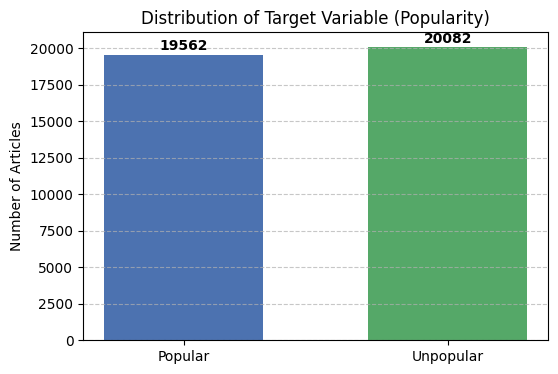

In [7]:
# 1. Visualization of Class Distribution
plt.figure(figsize=(6, 4))
counts = data.groupBy("label").count().toPandas()
counts['label_str'] = counts['label'].map({0: 'Unpopular', 1: 'Popular'})
plt.bar(counts['label_str'], counts['count'], color=['#4c72b0', '#55a868'], width=0.6)
plt.title('Distribution of Target Variable (Popularity)')
plt.ylabel('Number of Articles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add counts on top of bars
for i, v in enumerate(counts['count']):
    plt.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')
plt.show()

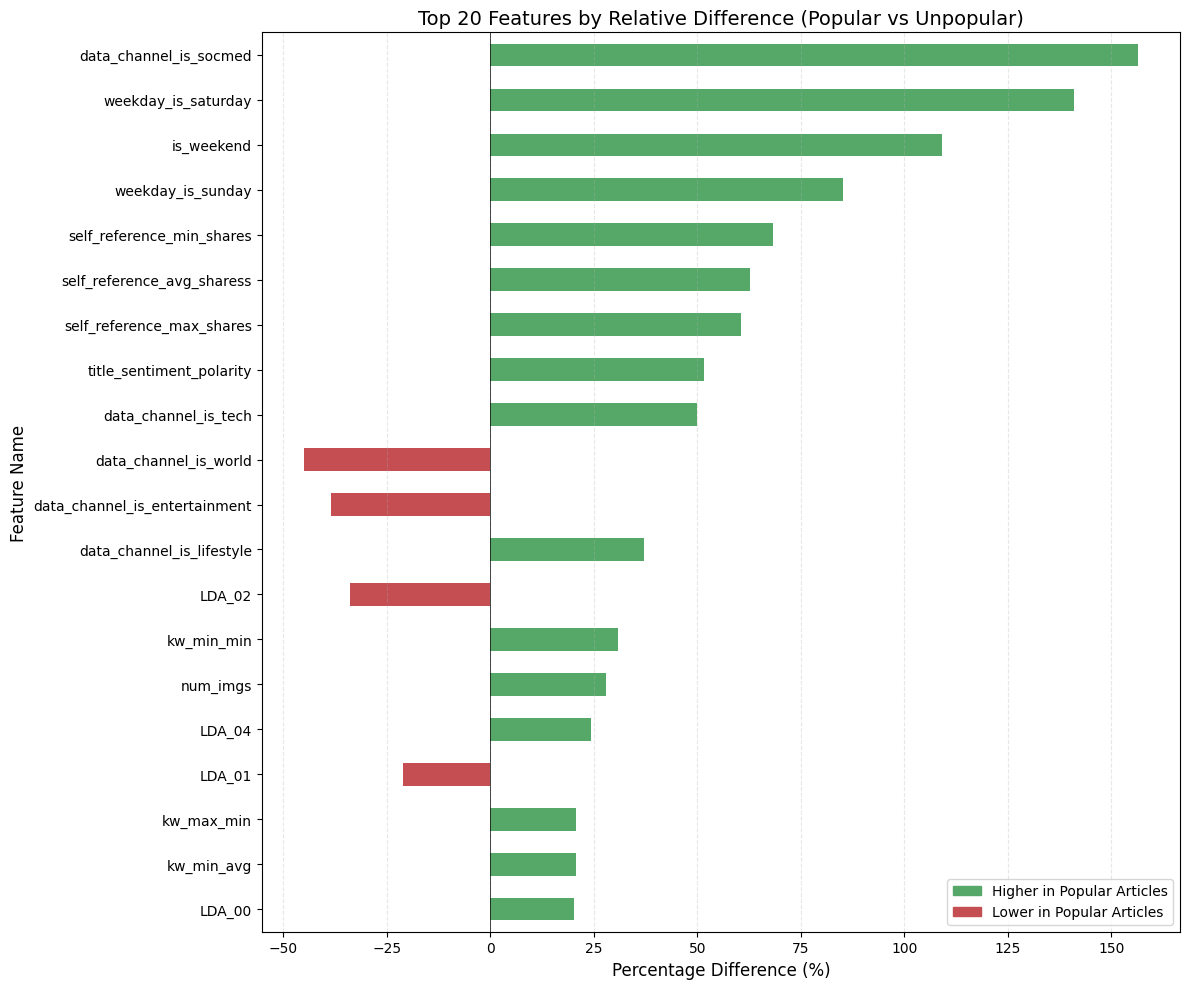

In [8]:
# 2. Visualization of Top Discriminative Features (based on % Diff calculated above)
plt.figure(figsize=(12, 10))

# Get top 20 features by absolute difference
top_diff_features = class_stats.sort_values('Abs_Diff', ascending=False).head(20)

# Plot
colors = ['#55a868' if x > 0 else '#c44e52' for x in top_diff_features['Diff (%)']]
top_diff_features['Diff (%)'].plot(kind='barh', color=colors)

plt.title('Top 20 Features by Relative Difference (Popular vs Unpopular)', fontsize=14)
plt.xlabel('Percentage Difference (%)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis() # Highest diff on top

# Add legend manually
import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#55a868', label='Higher in Popular Articles')
red_patch = mpatches.Patch(color='#c44e52', label='Lower in Popular Articles')
plt.legend(handles=[green_patch, red_patch], loc='lower right')

plt.tight_layout()
plt.show()

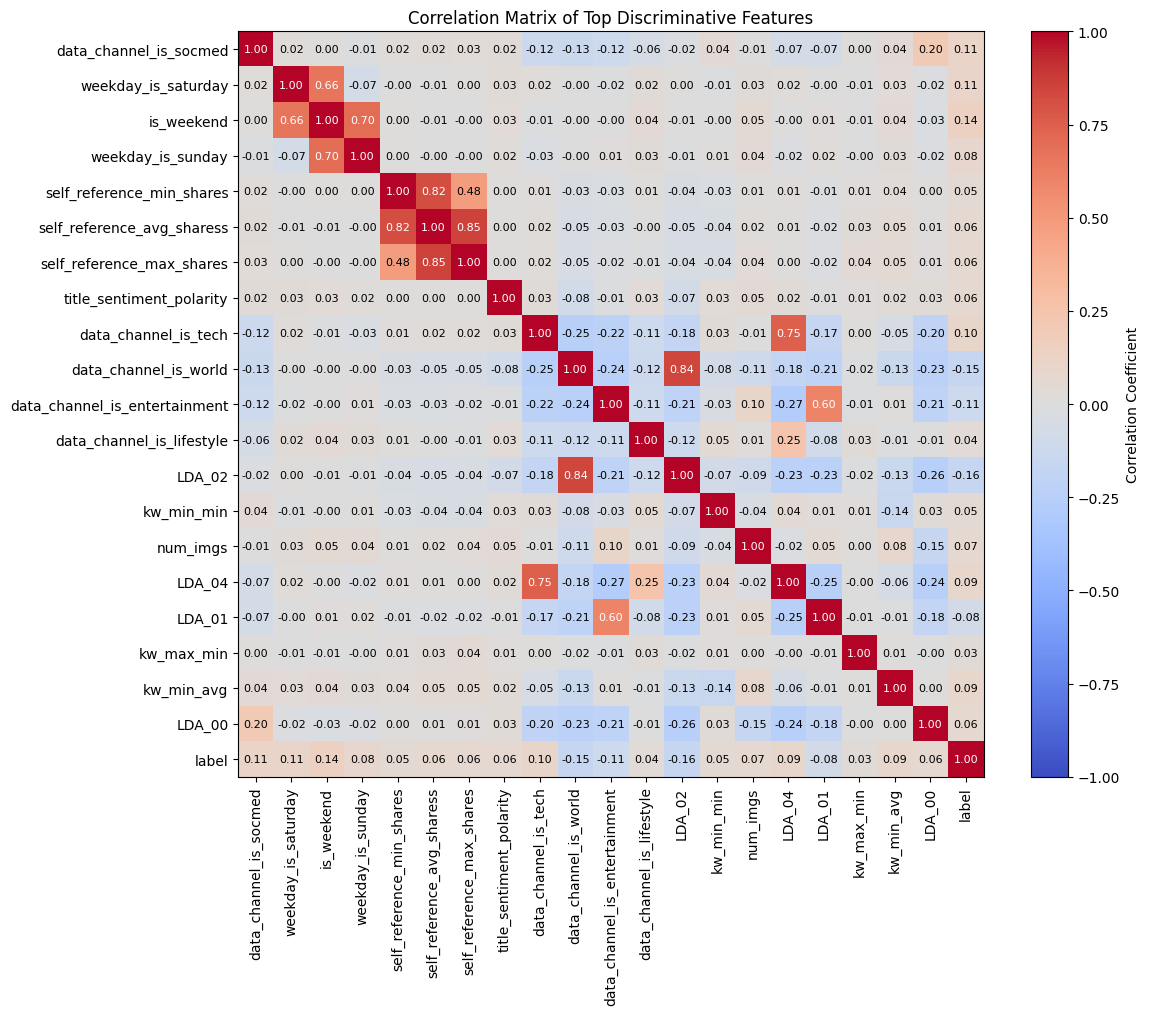

In [9]:
# 3. Correlation Matrix of Top Features
# We convert only the top discriminative features to Pandas to avoid memory issues with the full dataset
top_feature_names = top_diff_features.index.tolist()
selected_cols = top_feature_names + ['label']

# Create a sample to compute correlation (or full data if small enough, here full is ~40k which is fine)
# We cast to double to ensure correlation works
sampled_data_pd = data.select([col(c).cast('double') for c in selected_cols]).toPandas()

corr_matrix = sampled_data_pd.corr()

plt.figure(figsize=(12, 10))
# Using matplotlib basic imshow for correlation matrix
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
cb = plt.colorbar()
cb.set_label('Correlation Coefficient')

tick_marks = np.arange(len(corr_matrix.columns))
plt.xticks(tick_marks, corr_matrix.columns, rotation=90)
plt.yticks(tick_marks, corr_matrix.columns)
plt.title('Correlation Matrix of Top Discriminative Features')

# Add correlation values on the plot
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text_color = 'white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black'
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", 
                ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

### 2.3 Feature Selection

In [10]:
# Define feature columns (exclude url, timedelta, shares, and label)
# timedelta is kept for sorting but excluded from features
exclude_cols = ["url", "timedelta", "shares", "label"]
feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}...")  # Show first 10

Number of feature columns: 58
Feature columns: ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length']...


### 2.3 Feature Vectorization

> ⚠️ **Important Note on Scaling**: Features are vectorized here but **NOT scaled yet**. 
> 
> **Scaling will be applied separately within each rolling window** to prevent data leakage by ensuring the scaler is fitted only on training data.

In [11]:
# Assemble features into a single vector (but don't scale yet!)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_data = assembler.transform(data)

# Select only necessary columns (features are unscaled at this point)
# Scaling will be done separately for each rolling window to prevent data leakage
prepared_data = assembled_data.select("timedelta", "features", "label")

print("Feature assembly complete!")
print(f"Prepared data count: {prepared_data.count()}")
print("Note: Scaling will be applied separately within each rolling window to prevent data leakage")
prepared_data.show(5)

Feature assembly complete!
Prepared data count: 39644
Note: Scaling will be applied separately within each rolling window to prevent data leakage
+---------+--------------------+-----+
|timedelta|            features|label|
+---------+--------------------+-----+
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    1|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
+---------+--------------------+-----+
only showing top 5 rows


## 3. Rolling Window Time-Series Split

Following the methodology from the reference paper to ensure temporal validity:

| Parameter | Value | Description |
|-----------|-------|-------------|
| **Window size (W)** | 10,000 samples | Size of each training/testing window |
| **Step size (L)** | 1,000 samples | Number of samples to advance between windows |
| **Train/Validation split** | 70/30 | Ratio within each window |

This approach ensures that:
- ✅ **No future data leaks into past predictions**
- ✅ **Models are evaluated on truly unseen temporal data**
- ✅ **Consistent evaluation across different time periods**

In [12]:
# Sort data by timedelta in DESCENDING order (chronological: oldest → newest)
# timedelta = days between publication and acquisition
# Large timedelta = old articles (published long ago)
# Small timedelta = new articles (published recently)
# We want: old → new (past → future) for time-series prediction
sorted_data = prepared_data.orderBy(col("timedelta").desc())

# Cache the sorted data for efficiency
sorted_data.cache()

# Improved windowing parameters
W = 10000  # Base window size for train/evaluation split
L = 1000   # Step size AND test data size
total_window_size = W + L  # Total window size = 11,000
total_rows = sorted_data.count()

print(f"Total samples: {total_rows}")
print(f"Base window (W): {W} samples → split into 70% train + 30% evaluation")
print(f"Test size (L): {L} samples → future data for testing")
print(f"Total window size: {total_window_size} samples (W + L)")
print(f"Step size: {L} samples (advance between windows)")

# Calculate number of windows
num_windows = (total_rows - total_window_size) // L + 1
print(f"Number of rolling windows: {num_windows}")

Total samples: 39644
Base window (W): 10000 samples → split into 70% train + 30% evaluation
Test size (L): 1000 samples → future data for testing
Total window size: 11000 samples (W + L)
Step size: 1000 samples (advance between windows)
Number of rolling windows: 29


In [13]:
# Add sequential row numbers for window extraction
# Using Window.row_number() - ensures proper ordering by timedelta

# Note: Window is used here to add sequential indices, not for windowed aggregations
# Using desc() order to maintain chronological order (oldest first)
window_spec = Window.orderBy(col("timedelta").desc())
data_with_row = sorted_data.withColumn("row_num", row_number().over(window_spec))
data_with_row.cache()  # Cache only the base data with row numbers

# Force materialization of data_with_row
data_with_row.count()

sorted_data.unpersist()  # Unpersist original sorted data to save memory

# Calculate number of windows with new approach
total_window_size = W + L
num_windows_to_create = (total_rows - total_window_size) // L + 1
print(f"Will process {num_windows_to_create} windows sequentially with improved approach")
print(f"Each window: W+L={total_window_size} samples → Train+Eval+Test")
print("Benefits: Perfect temporal order, true future testing, memory efficient")

Will process 29 windows sequentially with improved approach
Each window: W+L=11000 samples → Train+Eval+Test
Benefits: Perfect temporal order, true future testing, memory efficient


## 4.  Helper Functions for Training and Evaluation

This section defines comprehensive utility functions to streamline the machine learning pipeline:

### **Evaluation Function**
- Calculates multiple performance metrics (AUC, Accuracy, F1-Score, Precision, Recall)
- Provides standardized model assessment across all algorithms

### **Training Function with Grid Search**
- Implements GridSearch within each rolling window
- Performs hyperparameter optimization via grid search
- Ensures consistent training methodology across all models

In [14]:
def create_window_on_demand(data_with_row, start, W, L, total_rows):
    """
    Create a single window on-demand and scaling.
    
    Window Structure:
    1. Extract W + L samples from the dataset
    2. First W samples → Train data (TVS splits this into train/validation internally)
    3. Last L samples → Test data (future)
    4. Fit scaler on train data (W samples) ONLY
    5. Apply scaler to both train + test data
    
    Args:
        data_with_row: Base DataFrame with row numbers
        start: Starting position for THIS window
        W: Base window size for train data
        L: Test data size (and step size)
        total_rows: Total number of rows
    
    Returns:
        Tuple: (train_scaled, test_scaled)
    """
    total_window_size = W + L
    end = start + total_window_size  # Window spans W + L samples
    
    # STEP 1: Extract W + L samples for THIS window
    window_data = data_with_row.filter((col("row_num") > start) & (col("row_num") <= end))
    
    # STEP 2: Split window into two parts
    train_end = start + W  # End of train data
    
    # First W samples as train data (TVS will split this internally)
    train_raw = window_data.filter((col("row_num") > start) & (col("row_num") <= train_end)).select("features", "label")
    
    # Last L samples as test data (future samples)
    test_raw = window_data.filter((col("row_num") > train_end) & (col("row_num") <= end)).select("features", "label")
    
    # STEP 3: CRITICAL - Fit scaler on train data ONLY (prevents data leakage)
    scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
    scaler_model = scaler.fit(train_raw)  # Fit only on training data (W samples)
    
    # STEP 4: Apply the SAME scaler to both train + test data
    train_scaled = scaler_model.transform(train_raw).select(col("scaled_features").alias("features"), "label")
    test_scaled = scaler_model.transform(test_raw).select(col("scaled_features").alias("features"), "label")
    
    return train_scaled, test_scaled

In [15]:
def evaluate_model(predictions):
    """
    Evaluate model predictions using multiple metrics
    
    Args:
        predictions: DataFrame with predictions
    
    Returns:
        Dictionary with evaluation metrics
    """
    # Binary classification evaluator for AUC
    binary_evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
    auc_score = binary_evaluator.evaluate(predictions)
    
    # Multiclass evaluator for other metrics
    mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    
    accuracy = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "accuracy"})
    f1 = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "f1"})
    precision = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedPrecision"})
    recall = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedRecall"})
    
    return {
        "AUC": auc_score,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

In [16]:
def train_single_algorithm_on_window(model, param_grid, train, test, model_name):
    """
    Train a single algorithm on a single window with grid search.
    
    Args:
        model: PySpark ML model (estimator)
        param_grid: ParamGrid with hyperparameters to search
        train: Scaled training data for this window
        test: Scaled test data for this window  
        model_name: Name of the model for display
    
    Returns:
        Tuple: (metrics_dict, predictions_df, best_params_dict)
    """
    # Create TrainValidationSplit for hyperparameter tuning
    tvs = TrainValidationSplit(
        estimator=model,
        estimatorParamMaps=param_grid,
        evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
        trainRatio=0.7,  # TVS splits train data into 70% train + 30% validation
        seed=42,
        parallelism=8
    )
    
    # STEP 1: Grid search on scaled train data (TVS handles internal 70/30 split)
    tvs_model = tvs.fit(train)
    
    # STEP 2: Extract best hyperparameters 
    best_model_from_validation = tvs_model.bestModel
    best_params = best_model_from_validation.extractParamMap()
    
    # Store best params for analysis
    best_params_dict = {param.name: value for param, value in best_params.items()}
    
    # STEP 3: Train final model on FULL scaled train data with best params
    final_model = model.copy(best_params)
    final_model = final_model.fit(train)
    
    # STEP 4: Evaluate on scaled test data (future samples)
    predictions = final_model.transform(test)
    
    # STEP 5: Calculate metrics and collect results
    metrics = evaluate_model(predictions)
    
    # Store predictions for ROC curve (collect to driver immediately)
    if "probability" in predictions.columns:
        pred_df = predictions.select("label", "probability").toPandas()
    else:
        # Fallback for models that don't output probability (like LinearSVC)
        # We select rawPrediction which contains the margin/score
        pred_df = predictions.select("label", "rawPrediction").toPandas()
    
    return metrics, pred_df, best_params_dict

def train_all_algorithms_efficiently(models_and_grids, data_with_row, total_rows, W, L):
    """
    Train all algorithms by traversing windows once.
    
    Instead of:
    - Train RF on all windows
    - Train GBT on all windows  
    - Train SVM on all windows
    
    We do:
    - For each window: Train RF + GBT + SVM, then move to next window
    
    Args:
        models_and_grids: List of (model, param_grid, model_name) tuples
        data_with_row: Base DataFrame with row numbers (cached)
        total_rows: Total number of rows
        W: Train data size
        L: Test size AND step size
    
    Returns:
        Dictionary with results for each algorithm
    """
    print(f"\n{'='*80}")
    print("All Algorithms on Each Window")
    print(f"{'='*80}")
    print(f"Training {len(models_and_grids)} algorithms efficiently:")
    for model, _, name in models_and_grids:
        print(f"  • {name}")
    
    # Initialize results storage for all algorithms
    results = {}
    for _, _, model_name in models_and_grids:
        results[model_name] = {
            'all_metrics': [],
            'all_predictions': [],
            'best_params_per_window': []
        }
    
    # Calculate number of windows
    total_window_size = W + L
    num_windows = (total_rows - total_window_size) // L + 1
    
    # Process each window once, train all algorithms
    for i, start in enumerate(range(0, total_rows - total_window_size + 1, L), 1):
        print(f"Processing window {i}/{num_windows} (samples {start} to {start+total_window_size-1})...")
        
        # STEP 1: Create window once (W + L samples)
        train, test = create_window_on_demand(data_with_row, start, W, L, total_rows)

        train.cache()
        test.cache()
        
        # STEP 2: Train ALL algorithms on this window
        for model, param_grid, model_name in models_and_grids:
            print(f"    → Training {model_name}...")
            
            # Train this algorithm on this window
            metrics, pred_df, best_params = train_single_algorithm_on_window(
                model, param_grid, train, test, model_name
            )
            
            # Store results for this algorithm
            results[model_name]['all_metrics'].append(metrics)
            results[model_name]['all_predictions'].append(pred_df)
            results[model_name]['best_params_per_window'].append(best_params)
            
            print(f"      AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")
        
        # STEP 3: Clean up memory from this window (done with all algorithms)
        train.unpersist()
        test.unpersist()
        
        print(f"  → Window {i} completed for all algorithms, memory freed\n")
    
    # STEP 4: Calculate average metrics for each algorithm
    final_results = {}
    for model_name in results.keys():
        all_metrics = results[model_name]['all_metrics']
        
        # Calculate average metrics across all windows
        avg_metrics = {}
        for metric_name in all_metrics[0].keys():
            avg_metrics[metric_name] = np.mean([m[metric_name] for m in all_metrics])
        
        final_results[model_name] = {
            'avg_metrics': avg_metrics,
            'all_metrics': results[model_name]['all_metrics'],
            'all_predictions': results[model_name]['all_predictions'],
            'best_params_per_window': results[model_name]['best_params_per_window']
        }
        
        print(f"{model_name} - Average Test Performance across {num_windows} windows:")
        print(f"  AUC:       {avg_metrics['AUC']:.4f}")
        print(f"  Accuracy:  {avg_metrics['Accuracy']:.4f}")
        print(f"  F1-Score:  {avg_metrics['F1-Score']:.4f}")
        print(f"  Precision: {avg_metrics['Precision']:.4f}")
        print(f"  Recall:    {avg_metrics['Recall']:.4f}\n")
    
    return final_results


# Algorithm 1: Logistic Regression

**Logistic Regression** is a linear model for binary classification that estimates the probability of an article being popular using the logistic (sigmoid) function.

### Hyperparameters Tuned:
- **Regularization Parameter (regParam)**: Controls overfitting
- **Elastic Net Parameter**: Balances L1 (Lasso) and L2 (Ridge) regularization

In [17]:
# Initialize Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

# Define parameter grid for Logistic Regression
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 1.0]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# Algorithm 2: Naive Bayes

**Naive Bayes** is a probabilistic classifier based on **Bayes' theorem** with the "naive" assumption of **feature independence**.

### Model Type:
- **Gaussian Naive Bayes**: Assumes continuous features follow a Gaussian (normal) distribution

### Hyperparameters Tuned:
- **Smoothing Parameter**: Prevents zero probability estimates for unseen feature combinations

In [18]:
# Initialize Naive Bayes model
# Note: Naive Bayes requires non-negative features for Multinomial/Bernoulli,
# but Gaussian handles continuous features which can be negative (from StandardScaler).
nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="gaussian"
)

# Define parameter grid for Naive Bayes
nb_param_grid = ParamGridBuilder() \
    .addGrid(nb.smoothing, [0.1, 0.5, 1.0]) \
    .build()

# Algorithm 3: Decision Tree Classifier

**Decision Tree** is a tree-based model that learns **decision rules** from data features to make predictions.

### Hyperparameters Tuned:
- **Maximum Depth**: Controls tree complexity and overfitting
- **Minimum Information Gain**: Threshold for splitting nodes
- **Impurity Measure**: Gini vs. Entropy for split quality evaluation


In [19]:
# Initialize Decision Tree model
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
)

# Define parameter grid for Decision Tree
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5, 10]) \
    .addGrid(dt.minInfoGain, [0.0, 0.01]) \
    .addGrid(dt.impurity, ["gini", "entropy"]) \
    .build()

In [20]:
# Add row number to data for windowing if not already present
# We define data_with_row here to ensure it's available for helper function
window_spec = Window.orderBy(col("timedelta").desc())
data_with_row = sorted_data.withColumn("row_num", row_number().over(window_spec))
data_with_row.cache()

# Define all models and their parameter grids
models_and_grids = [
    (lr, lr_param_grid, "Logistic Regression"),
    (nb, nb_param_grid, "Naive Bayes"), 
    (dt, dt_param_grid, "Decision Tree")
]

# Train all algorithms efficiently (traverse windows once)
all_results = train_all_algorithms_efficiently(
    models_and_grids, data_with_row, total_rows, W, L
)

# Extract results for each algorithm
lr_metrics = all_results["Logistic Regression"]['avg_metrics']
lr_predictions = all_results["Logistic Regression"]['all_predictions']
lr_best_params = all_results["Logistic Regression"]['best_params_per_window']

nb_metrics = all_results["Naive Bayes"]['avg_metrics']
nb_predictions = all_results["Naive Bayes"]['all_predictions']
nb_best_params = all_results["Naive Bayes"]['best_params_per_window']

dt_metrics = all_results["Decision Tree"]['avg_metrics']
dt_predictions = all_results["Decision Tree"]['all_predictions']
dt_best_params = all_results["Decision Tree"]['best_params_per_window']


All Algorithms on Each Window
Training 3 algorithms efficiently:
  • Logistic Regression
  • Naive Bayes
  • Decision Tree
Processing window 1/29 (samples 0 to 10999)...
    → Training Logistic Regression...


      AUC: 0.6838, Accuracy: 0.6360
    → Training Naive Bayes...
      AUC: 0.4476, Accuracy: 0.6320
    → Training Decision Tree...
      AUC: 0.5257, Accuracy: 0.5310
  → Window 1 completed for all algorithms, memory freed

Processing window 2/29 (samples 1000 to 11999)...
    → Training Logistic Regression...
      AUC: 0.7124, Accuracy: 0.6730
    → Training Naive Bayes...
      AUC: 0.5044, Accuracy: 0.6190
    → Training Decision Tree...
      AUC: 0.6313, Accuracy: 0.6170
  → Window 2 completed for all algorithms, memory freed

Processing window 3/29 (samples 2000 to 12999)...
    → Training Logistic Regression...
      AUC: 0.6742, Accuracy: 0.6290
    → Training Naive Bayes...
      AUC: 0.4585, Accuracy: 0.5920
    → Training Decision Tree...
      AUC: 0.5958, Accuracy: 0.6190
  → Window 3 completed for all algorithms, memory freed

Processing window 4/29 (samples 3000 to 13999)...
    → Training Logistic Regression...
      AUC: 0.6823, Accuracy: 0.6470
    → Training Naiv

### Model Comparison

Performance comparison to identify the best-performing approach for online news popularity prediction.

              Model      AUC  Accuracy  F1-Score  Precision   Recall
Logistic Regression 0.708038  0.655690  0.654468   0.659649 0.655690
        Naive Bayes 0.480849  0.601793  0.574745   0.616188 0.601793
      Decision Tree 0.581817  0.623621  0.619581   0.633202 0.623621

Best AUC: Logistic Regression (0.7080)
Best Accuracy: Logistic Regression (0.6557)
Best F1-Score: Logistic Regression (0.6545)
Best Precision: Logistic Regression (0.6596)
Best Recall: Logistic Regression (0.6557)


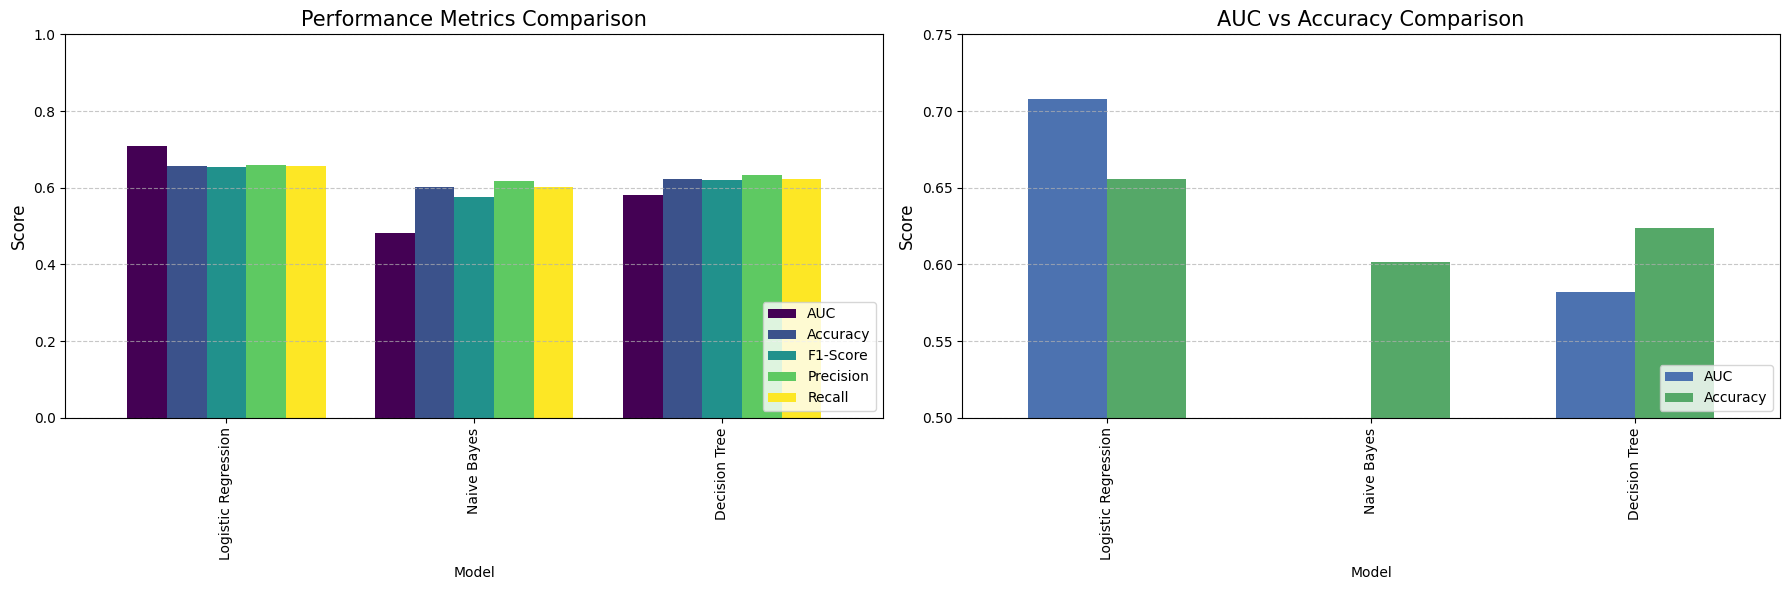

In [21]:
# Comparison of 3 algorithms implemented in this notebook (3CFU)
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Naive Bayes', 'Decision Tree'
    ],
    'AUC': [
        lr_metrics['AUC'], nb_metrics['AUC'], dt_metrics['AUC']
    ],
    'Accuracy': [
        lr_metrics['Accuracy'], nb_metrics['Accuracy'], dt_metrics['Accuracy']
    ],
    'F1-Score': [
        lr_metrics['F1-Score'], nb_metrics['F1-Score'], dt_metrics['F1-Score']
    ],
    'Precision': [
        lr_metrics['Precision'], nb_metrics['Precision'], dt_metrics['Precision']
    ],
    'Recall': [
        lr_metrics['Recall'], nb_metrics['Recall'], dt_metrics['Recall']
    ]
})

print(comparison_df.to_string(index=False))

# Find best performing model for each metric
print(f"\nBest AUC: {comparison_df.loc[comparison_df['AUC'].idxmax(), 'Model']} ({comparison_df['AUC'].max():.4f})")
print(f"Best Accuracy: {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"Best F1-Score: {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"Best Precision: {comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']} ({comparison_df['Precision'].max():.4f})")
print(f"Best Recall: {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Bar chart for all metrics
metrics_to_plot = ['AUC', 'Accuracy', 'F1-Score', 'Precision', 'Recall']
comparison_df.set_index('Model')[metrics_to_plot].plot(
    kind='bar', 
    ax=axes[0],
    colormap='viridis',
    width=0.8
)
axes[0].set_title('Performance Metrics Comparison', fontsize=15)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Zoomed in Bar chart for AUC & Accuracy
comparison_df.set_index('Model')[['AUC', 'Accuracy']].plot(
    kind='bar', 
    ax=axes[1],
    color=['#4c72b0', '#55a868'],
    width=0.6
)
axes[1].set_title('AUC vs Accuracy Comparison', fontsize=15)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_ylim(0.5, 0.75) # Zoom in to see differences
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot Performance Over Time (Across Rolling Windows)

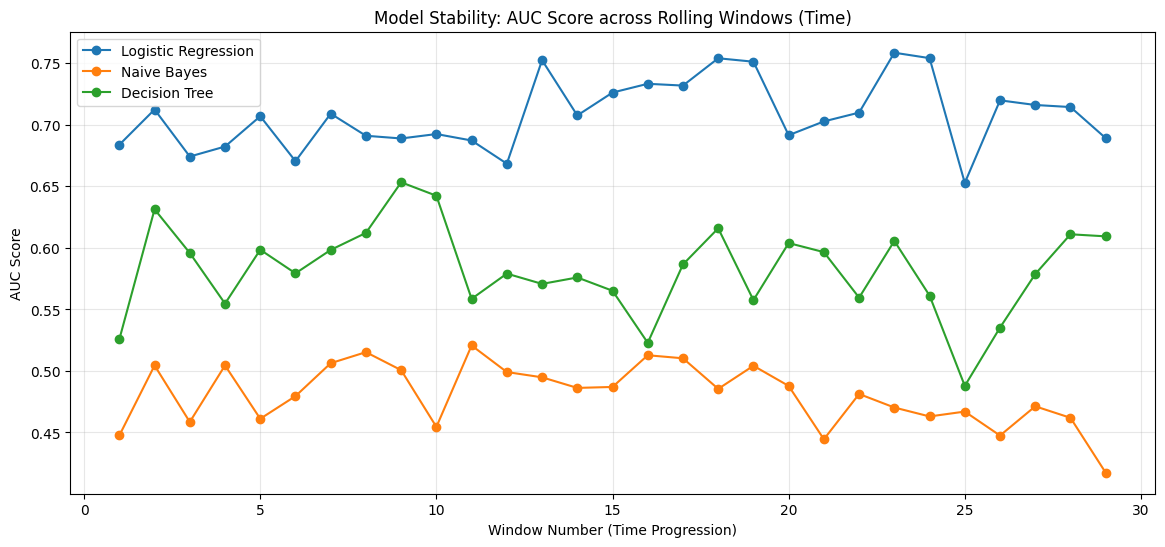

In [22]:
# Plot Performance Over Time (Across Rolling Windows)
plt.figure(figsize=(14, 6))

models_metrics = [
    ("Logistic Regression", all_results["Logistic Regression"]['all_metrics']),
    ("Naive Bayes", all_results["Naive Bayes"]['all_metrics']),
    ("Decision Tree", all_results["Decision Tree"]['all_metrics'])
]

for name, metrics_list in models_metrics:
    # Extract AUC for each window
    aucs = [m['AUC'] for m in metrics_list]
    windows = range(1, len(aucs) + 1)
    
    plt.plot(windows, aucs, marker='o', label=name)

plt.title("Model Stability: AUC Score across Rolling Windows (Time)")
plt.xlabel("Window Number (Time Progression)")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best params in each window

In [23]:
import collections

def analyze_best_params(model_name, params_list, param_grid=None):
    print(f"\n--- Hyperparameter Analysis for {model_name} ---")
    
    # Determine which parameters to analyze
    allowed_params = None
    if param_grid and len(param_grid) > 0:
        # Extract parameter names from the first map in the grid
        # param_grid is a list of dicts {Param: value}, we extract Param.name
        allowed_params = set()
        for param_map in param_grid: # Iterate all maps to be safe, though keys usually same
             for param in param_map.keys():
                 allowed_params.add(param.name)
    
    # Flatten the list of dictionaries into a dictionary of lists
    param_counts = collections.defaultdict(list)
    
    for window_params in params_list:
        for param_name, value in window_params.items():
            # If allowed_params is set, only include those parameters
            if allowed_params is None or param_name in allowed_params:
                param_counts[param_name].append(value)
            
    # Print most frequent choice for each parameter
    for param_name, values in param_counts.items():
        counter = collections.Counter(values)
        print(f"Parameter: {param_name}")
        for val, count in counter.most_common():
            print(f"  • Value: {val} (selected in {count} windows)")

# Run analysis for your models
analyze_best_params("Logistic Regression", lr_best_params, lr_param_grid)
analyze_best_params("Naive Bayes", nb_best_params, nb_param_grid)
analyze_best_params("Decision Tree", dt_best_params, dt_param_grid)


--- Hyperparameter Analysis for Logistic Regression ---
Parameter: elasticNetParam
  • Value: 0.0 (selected in 21 windows)
  • Value: 0.5 (selected in 8 windows)
Parameter: regParam
  • Value: 0.01 (selected in 29 windows)

--- Hyperparameter Analysis for Naive Bayes ---
Parameter: smoothing
  • Value: 0.1 (selected in 29 windows)

--- Hyperparameter Analysis for Decision Tree ---
Parameter: impurity
  • Value: gini (selected in 24 windows)
  • Value: entropy (selected in 5 windows)
Parameter: maxDepth
  • Value: 10 (selected in 16 windows)
  • Value: 5 (selected in 13 windows)
Parameter: minInfoGain
  • Value: 0.01 (selected in 23 windows)
  • Value: 0.0 (selected in 6 windows)


### ROC Curves 

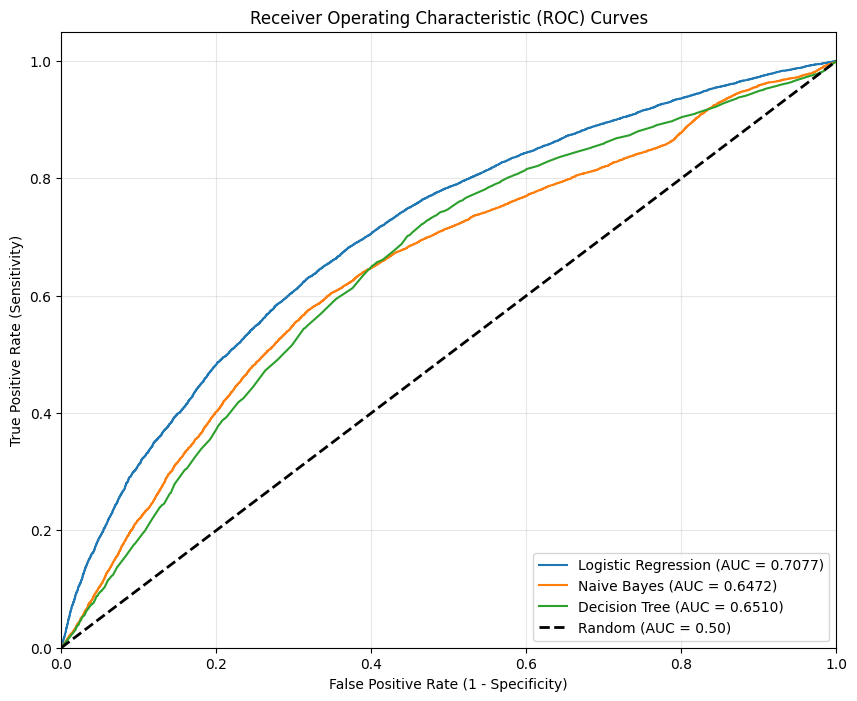

In [24]:
# Plot ROC Curves for all algorithms
plt.figure(figsize=(10, 8))

# Define predictions list for iteration
predictions_list = [
    (lr_predictions, "Logistic Regression"),
    (nb_predictions, "Naive Bayes"),
    (dt_predictions, "Decision Tree")
]

for pred_dist_list, model_name in predictions_list:
    # Concatenate predictions from all windows
    all_labels = []
    all_scores = []
    
    for df in pred_dist_list:
        all_labels.extend(df['label'].values)
        
        # Extract probability for class 1
        if 'probability' in df.columns:
            # probability is a dense vector, we need the 2nd element (index 1) which is prob of class 1
            # In pandas from spark, it often comes as an array/list within the cell or a string representation
            # We need to handle this carefully.
            # Assuming standard behavior where toPandas() converts vector to list/array
             all_scores.extend([row[1] for row in df['probability']])
        elif 'rawPrediction' in df.columns:
             # For models like LinearSVC, use rawPrediction (margin)
             # But here we have LR, NB, DT, all should have probability.
             # If not, fallback to rawPrediction index 1
             all_scores.extend([row[1] for row in df['rawPrediction']])

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()